In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [192]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, KBinsDiscretizer, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

In [113]:
df = pd.read_csv('../Basic DS Tutorial/data/titanic.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [114]:
df['family'] = df['SibSp'] + df['Parch']
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,Fare,Embarked,family
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,0
887,1,1,female,19.0,30.0000,S,0
888,0,3,female,NaN,23.4500,S,3
889,1,1,male,26.0,30.0000,C,0


In [115]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], train_size=0.8, random_state=42)

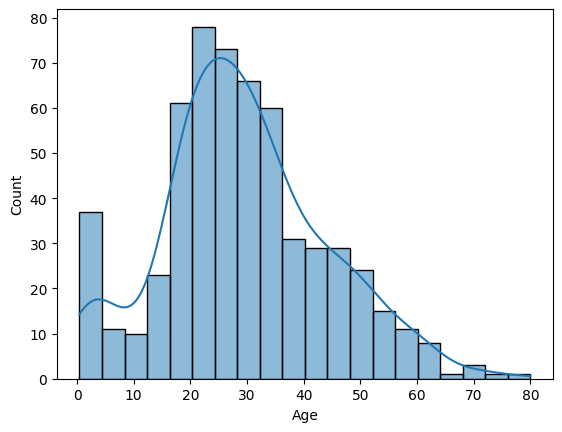

<Axes: ylabel='Age'>

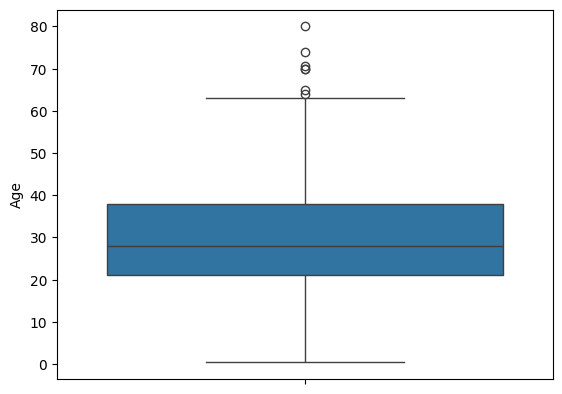

In [136]:
sns.histplot(X_train['Age'], kde=True)
plt.show()
sns.boxplot(X_train['Age'])

<Axes: ylabel='Age'>

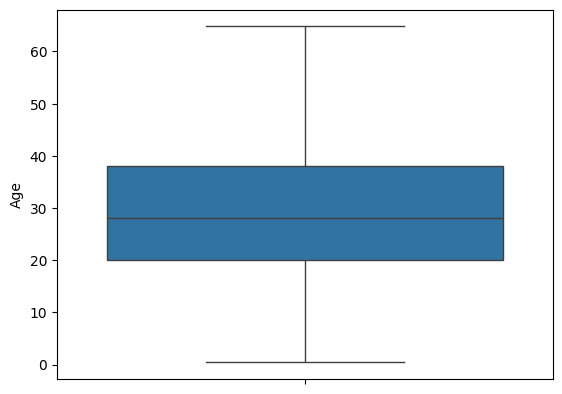

In [102]:
sns.boxplot(np.clip(df['Age'], df['Age'].quantile(0.25)-1.5*(df['Age'].quantile(0.75) - df['Age'].quantile(0.25)), df['Age'].quantile(0.75)+1.5*(df['Age'].quantile(0.75) - df['Age'].quantile(0.25))))

In [119]:
X_train.isnull().mean()

Pclass      0.000000
Sex         0.000000
Age         0.196629
Fare        0.000000
Embarked    0.002809
family      0.000000
dtype: float64

In [125]:
X_train

,Pclass,Sex,Age,Fare,Embarked,family
331,1,male,45.5,28.5000,S,0
733,2,male,23.0,13.0000,S,0
382,3,male,32.0,7.9250,S,0
704,3,male,26.0,7.8542,S,1
813,3,female,6.0,31.2750,S,6
...,...,...,...,...,...,...
106,3,female,21.0,7.6500,S,0
270,1,male,NaN,31.0000,S,0
860,3,male,41.0,14.1083,S,2
435,1,female,14.0,120.0000,S,3


In [138]:
X_train['Fare'].describe()

count    712.000000
mean      32.586276
std       51.969529
min        0.000000
25%        7.925000
50%       14.454200
75%       30.500000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Count'>

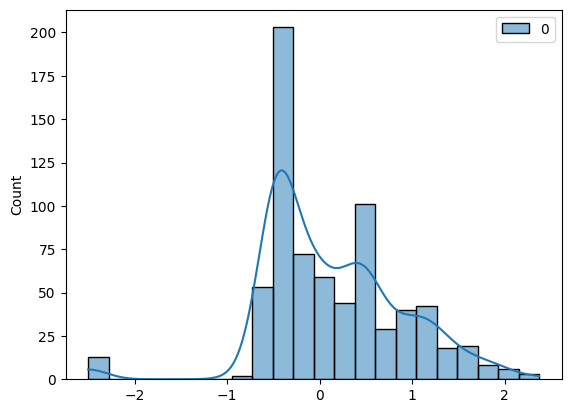

In [155]:
sns.histplot(RobustScaler().fit_transform(PowerTransformer().fit_transform(X_train[['Fare']])), kde=True)

In [164]:
age_pipe = Pipeline([
    ('age_impute', SimpleImputer(strategy='median')),
    ('age_bin', KBinsDiscretizer(n_bins=3, encode='ordinal')),
    ('age_ohe', OneHotEncoder(drop='first', sparse_output=False))
])

fare_pipe = Pipeline([
    ('fare_power', PowerTransformer()),
    ('fare_scale', RobustScaler())
])

emb_pipe = Pipeline([
    ('embark_impute', SimpleImputer(strategy='most_frequent')),
    ('embark_ohe', OneHotEncoder(drop='first', sparse_output=False)),
])

trf = ColumnTransformer(transformers=[
    ('sex_trf', OneHotEncoder(drop='first', sparse_output=False), [1]),
    ('age_trf', age_pipe, [2]),
    ('fare_trf', fare_pipe, [3]),
    ('embark_trf', emb_pipe, [4])
], remainder='passthrough')

In [166]:
X_train = trf.fit_transform(X_train)
X_test = trf.transform(X_test)

/home/aryan/Desktop/code/Python/venv/lib64/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [186]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [187]:
y_pred = lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.7877094972067039

In [189]:
sgd = SGDClassifier()

GridSearchCV(sgd, {
    "loss":['hinge', 'log_loss', 'log'],
    "penalty":['l1', 'l2', None, "elasticnet"],
    "alpha":[0.001, 0.1, 0.01, 0.25, 0.5, 0.4, 0.7],
    "l1_ratio":[0.01, 0.05, 0.1, 0.25, 0.4, 0.5, 0.7, 0.8],
    "max_iter":[10,50,100,500,1000,2000],
    # "learning_rate":['constant', 'adaptive', 'optimal'],
    "eta0":[0.01, 0.1, 0.04, 0.06]
}, n_jobs=-1, cv=5, scoring='accuracy').fit(X_train, y_train)

/home/aryan/Desktop/code/Python/venv/lib64/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/aryan/Desktop/code/Python/venv/lib64/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/aryan/Desktop/code/Python/venv/lib64/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/aryan/Desktop/code/Python/venv/lib64/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_it

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.1, ...], 'eta0': [0.01, 0.1, ...], 'l1_ratio': [0.01, 0.05, ...], 'loss': ['hinge', 'log_loss', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [190]:
s = SGDClassifier(alpha=0.25, eta0=0.06, l1_ratio=0.25, loss='log_loss',
              max_iter=500, penalty=None)
s.fit(X_train, y_train)
yp = s.predict(X_test)
accuracy_score(y_test, yp)

0.770949720670391

In [191]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
ypr = dt.predict(X_test)
accuracy_score(y_test, ypr)

0.7988826815642458

In [205]:
X_train

array([[1., 0., 1., ..., 1., 1., 0.],
       [1., 0., 0., ..., 1., 2., 0.],
       [1., 0., 1., ..., 1., 3., 0.],
       ...,
       [1., 0., 1., ..., 1., 3., 2.],
       [0., 0., 0., ..., 1., 1., 3.],
       [1., 0., 0., ..., 1., 1., 1.]], shape=(712, 8))

<Axes: >

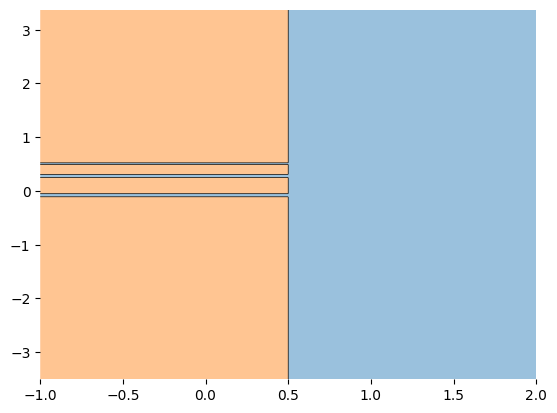

In [206]:
plot_decision_regions(X_train, y_train.values, clf=dt, feature_index=[0,3], filler_feature_values={
    1:np.mean(X_train[:,1]),
    2:np.mean(X_train[:,2]),
    4:np.mean(X_train[:,1]),
    5:np.mean(X_train[:,5]),
    6:np.mean(X_train[:,6]),
    7:np.mean(X_train[:,7])
})

In [197]:
dt.feature_importances_

array([0.34645185, 0.02434008, 0.04373476, 0.3665787 , 0.00832459,
       0.02095627, 0.12975328, 0.05986047])